# Getting Started with Smooth Lotteries (Review-Level Walkthrough)

This notebook gives an end-to-end example using **review-level Swiss NSF data**:

1. Load raw reviewer scores per proposal.
2. Normalize scores to `[0,1]`.
3. Set utility to the **mean normalized review score**.
4. Set smoothness parameters from review counts.
5. Run smooth Linear Lottery and smooth Top-k Softmax.
6. Compare marginals and sampled winner sets.

It keeps **all proposals** and uses all available reviews per proposal.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from smooth_lotteries import linear_lottery_smooth, softmax_topk_smooth


## 1) Load review-level Swiss NSF data

`mint_sections.csv` has one row per `(proposal, assessor, section)` with numeric score `num_grade` on a 1-6 scale.


In [2]:
path = Path('baselines/data/SwissNSFData/mint_sections.csv')
df = pd.read_csv(path)
df = df[['proposal', 'assessor', 'section', 'num_grade']].copy()

df.head()


,proposal,assessor,section,num_grade
0,proposal1_1,voter1,one,6
1,proposal1_1,voter3,one,6
2,proposal1_1,voter4,one,6
3,proposal1_1,voter5,one,6
4,proposal1_1,voter6,one,6


In [3]:
review_counts = df.groupby('proposal').size().rename('n_reviews')
review_counts.describe()


count    353.000000
mean       8.039660
std        0.803834
min        5.000000
25%        8.000000
50%        8.000000
75%        9.000000
max        9.000000
Name: n_reviews, dtype: float64

## 2) Build a review matrix

Review counts vary by proposal. We keep all proposals, pad shorter rows with `NaN`, and then use `nanmean` when computing utilities.


In [4]:
# Deterministic ordering for reproducibility.
df_sorted = df.sort_values(['proposal', 'assessor', 'section']).reset_index(drop=True)
grouped = df_sorted.groupby('proposal')['num_grade'].apply(list)

proposals = grouped.index.to_numpy()
lengths = grouped.apply(len).to_numpy()
r_min = int(lengths.min())
r_max = int(lengths.max())

# Pad the scores with NaN to create a 2D array of shape (n_proposals, r_max).
X_raw = np.full((len(grouped), r_max), np.nan, dtype=float)
for i, scores in enumerate(grouped.to_list()):
    vals = np.asarray(scores, dtype=float)
    X_raw[i, :len(vals)] = vals

n = X_raw.shape[0]
print(f"Proposals: n={n}")
print(f"Review counts range: r_min={r_min}, r_max={r_max}")
print(f"X_raw shape: {X_raw.shape}")


Proposals: n=353
Review counts range: r_min=5, r_max=9
X_raw shape: (353, 9)


## 3) Normalize scores and define utility

Swiss NSF scores are on a 1-6 raw scale. Normalize each observed review to lie in $[0,1]$ as:

$x_{ij} = (x_{ij}^{raw} - 1) / (6 - 1)$

Utility for proposal $i$ is the mean normalized score over observed reviews:

$v_i = \frac{1}{r_i}\sum_{j=1}^{r_i} x_{ij}$.

In [5]:
score_min, score_max = 1.0, 6.0
X = (X_raw - score_min) / (score_max - score_min)
v = np.nanmean(X, axis=1)

print('X observed min/max:', float(np.nanmin(X)), float(np.nanmax(X)))
print('v min/max:', float(v.min()), float(v.max()))
print('First 10 utilities:', np.round(v[:10], 4))


X observed min/max: 0.0 1.0
v min/max: 0.0 1.0
First 10 utilities: [0.8    0.8    0.85   0.825  0.7778 0.8    0.84   0.8    0.775  0.8   ]


## 4) Set smoothness parameter

With variable review counts, a conservative global sensitivity bound for mean utility is:

$D_v = 1/r_{min}$

because each proposal has at least `r_min` reviews.


In [6]:
L = 1.0
D_v = 1.0 / r_min
k = int(round(0.33 * n))
k = max(1, min(k, n - 1))

print(f"n={n}, k={k}, L={L}, D_v={D_v:.4f}")


n=353, k=116, L=1.0, D_v=0.2000


## 5) Run smooth Linear Lottery

`linear_lottery_smooth` returns exact marginals `p` and one sampled winner set.


In [7]:
p_linear, sample_linear = linear_lottery_smooth(v=v, k=k, L=L, D_v=D_v)

print('sum(p_linear):', round(float(p_linear.sum()), 6))
print('sample size:', len(sample_linear))
print('first 15 selected indices:', sorted(sample_linear)[:15])


sum(p_linear): 116.0
sample size: 116
first 15 selected indices: [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17]


## 6) Run smooth Top-k Softmax

Top-k Softmax marginals are **Monte Carlo estimates**:
- draw Gumbel noise,
- take top-`k`,
- estimate marginals from selection frequencies.

Here we use `n_samples=100_000`. Larger `n_samples` reduces Monte Carlo error.


In [8]:
p_soft, sample_soft = softmax_topk_smooth(
    v=v,
    k=k,
    L=L,
    D_v=D_v,
    n_samples=100_000,
    rng=np.random.default_rng(1),
)

print('sum(p_soft):', round(float(p_soft.sum()), 6))

sum(p_soft): 116.0


## 7) Compare marginals

The x-axis is deduplicated utility values (not rank). For each utility value, we average marginals across proposals at that utility.


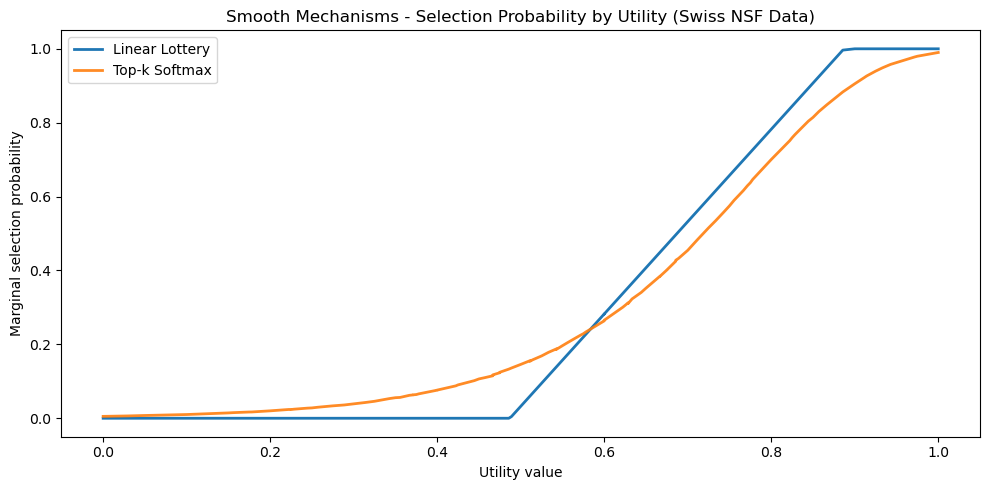

In [10]:
# Aggregate by unique utility values and plot mean marginals at each utility level.
plot_df = pd.DataFrame({
    'utility': v,
    'p_linear': p_linear,
    'p_softmax': p_soft,
})

agg = (
    plot_df
    .groupby('utility', as_index=False)
    .agg(
        p_linear=('p_linear', 'mean'),
        p_softmax=('p_softmax', 'mean'),
        count=('utility', 'size'),
    )
    .sort_values('utility')
)

plt.figure(figsize=(10, 5))
plt.plot(agg['utility'], agg['p_linear'], label='Linear Lottery', linewidth=2)
plt.plot(agg['utility'], agg['p_softmax'], label='Top-k Softmax', linewidth=2, alpha=0.9)
plt.xlabel('Utility value')
plt.ylabel('Marginal selection probability')
plt.title('Smooth Mechanisms - Selection Probability by Utility (Swiss NSF Data)')
plt.legend()
plt.tight_layout()
plt.show()


## 8) Compare sampled winner sets

Both methods output one random winner set of size `k`.


In [ ]:
winners_linear = set(sample_linear)
winners_soft = set(sample_soft)

print('Linear winners:', len(winners_linear))
print('Softmax winners:', len(winners_soft))
print('Overlap:', len(winners_linear & winners_soft))
print('Only linear:', len(winners_linear - winners_soft))
print('Only softmax:', len(winners_soft - winners_linear))


## Summary

This workflow loads raw reviews, normalizes to `[0,1]`, builds mean-utility scores, sets `D_v=1/r_min`, and compares smooth Linear Lottery vs smooth Top-k Softmax on both marginals and one sampled outcome.
